<a href="https://colab.research.google.com/github/mariavicksflor-glitch/Prog_Civil_2026_1/blob/main/Programaciontrabajogrupo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Integrantes:

NARVAEZ ROMERO, SHARICK

PEREZ FLOREZ, YERELYN

Carrascal Pastor, Kevyn

Puertas Peralta, Juan David

Romero Méndez, Samuel David

Flórez Martínez, María Victoria


**Planteamiento de la Situación y Conceptualización**


Este proyecto resuelve un problema clásico del diseño y evaluación de canales abiertos para el transporte de agua, aplicable a alcantarillados pluviales y canales de riego.El objetivo es construir un programa en Python que calcule el Caudal que puede transportar un canal abierto. El programa evaluará dos tipos de sección: rectangular y trapezoidal. Además, calculará el caudal para una serie de diferentes profundidades del agua (tirantes) utilizando un ciclo repetitivo, para evaluar su comportamiento ante el aumento del nivel del agua.Fundamento Teórico: Ecuación de ManningLa velocidad del flujo en un canal abierto se rige por la ecuación de Manning:

$$v = \frac{1}{n} \cdot R_h^{2/3} \cdot S^{1/2}$$El caudal total se obtiene multiplicando la velocidad por el área de la sección transversal ($Q = v \cdot A$):$$Q = \frac{1}{n} \cdot A \cdot R_h^{2/3} \cdot S^{1/2}$$

**Donde:**

$Q$: Caudal (m³/s).

$n$: Coeficiente de rugosidad de Manning (adimensional, depende del material).

$A$: Área de la sección transversal (m²).

$S$: Pendiente longitudinal del canal (m/m).

$R_h$: Radio hidráulico (m), definido como el Área dividida por el Perímetro mojado ($P$).

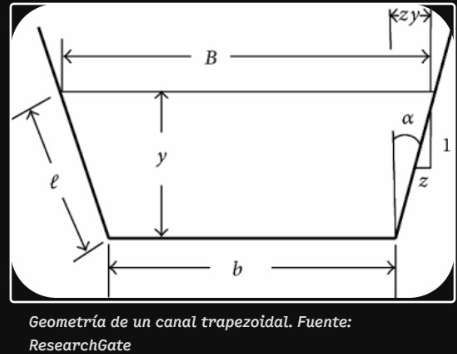

$$R_h = \frac{A}{P}$$

In [ ]:
#Definición de Funciones Geométricas y de Caudal

def calcular_geometria(tipo, b, y, z=0):
    """
    #Calcula el Área (A) y el Perímetro mojado (P) según el tipo de canal.
    """
    if tipo == "rectangular":
        A = b * y
        P = b + 2 * y
    elif tipo == "trapezoidal":
        A = (b + z * y) * y
        P = b + 2 * y * (1 + z**2)**0.5
    else:
        print("Tipo de canal no reconocido")
        return None, None

    return A, P

def calcular_caudal(A, P, n, S):
    """
    Calcula el Radio Hidráulico (Rh) y el Caudal (Q) usando la Ec. de Manning.
    """

    Rh = A / P
    # Fórmula: Q = (1/n) * A * (Rh^(2/3)) * (S^(1/2))
    Q = (1/n) * A * (Rh**(2/3)) * (S**0.5)
    return Rh, Q

print("Funciones cargadas correctamente.")

Funciones cargadas correctamente.


In [ ]:
# Simulación y Ciclo Repetitivo

# 1. Definición de parámetros fijos (Datos de los datos de validación)
b = 2.0      # Ancho de base (m)
n = 0.015    # Coeficiente de rugosidad de Manning (Concreto)
S = 0.001    # Pendiente longitudinal del canal (m/m)
z = 1.5      # Relación de talud lateral (solo para el canal trapezoidal)

# 2. Lista de profundidades (tirantes) a evaluar
tirantes = [0.5, 1.0, 1.5, 2.0]

# 3. Creación de listas vacías para almacenar los caudales calculados
caudales_rect = []
caudales_trap = []

# Imprimir encabezado para la tabla de resultados en consola
print(f"{'Profundidad (y)':<18} {'Caudal Rect. (m³/s)':<22} {'Caudal Trap. (m³/s)':<22}")
print("-" * 65)

# 4. Ciclo repetitivo para evaluar cada profundidad
for y in tirantes:

    # --- SIMULACIÓN CANAL RECTANGULAR ---
    # Calculamos el área y perímetro para el canal rectangular
    A_rect, P_rect = calcular_geometria(tipo="rectangular", b=b, y=y)
    # Calculamos el caudal con la ecuación de Manning
    _, Q_rect = calcular_caudal(A_rect, P_rect, n, S)
    # Guardamos el resultado en la lista correspondiente
    caudales_rect.append(Q_rect)

    # --- SIMULACIÓN CANAL TRAPEZOIDAL ---
    # Calculamos el área y perímetro incluyendo el talud z
    A_trap, P_trap = calcular_geometria(tipo="trapezoidal", b=b, y=y, z=z)
    # Calculamos el caudal
    _, Q_trap = calcular_caudal(A_trap, P_trap, n, S)
    # Guardamos el resultado en la otra lista
    caudales_trap.append(Q_trap)

    # Mostramos los resultados en la tabla formateados a 3 decimales
    print(f"{y:<18.1f} {Q_rect:<22.3f} {Q_trap:<22.3f}")

Profundidad (y)    Caudal Rect. (m³/s)    Caudal Trap. (m³/s)   
-----------------------------------------------------------------
0.5                1.014                  1.471                 
1.0                2.656                  5.390                 
1.5                4.499                  12.159                
2.0                6.435                  22.269                


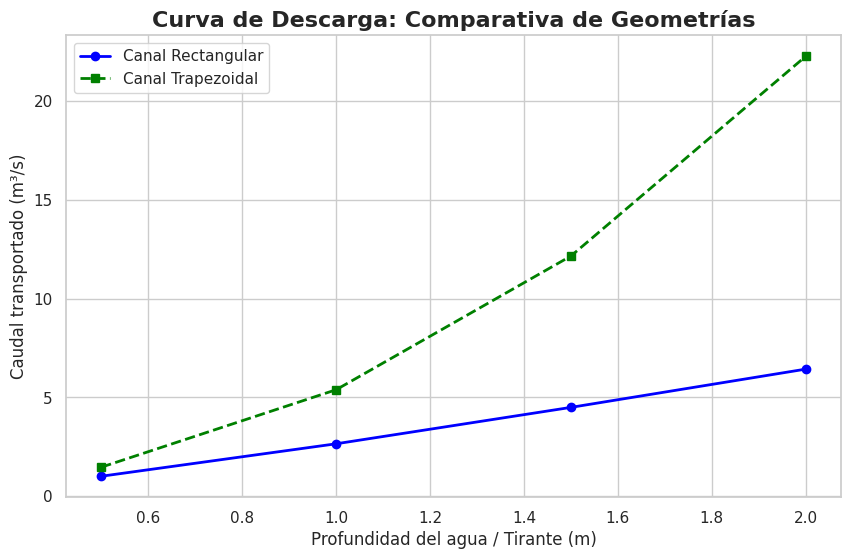

¡Simulación completada con éxito!


In [ ]:
#Visualización de Resultados (Gráfica)

import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo de la gráfica
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Graficamos la curva para el canal Rectangular
plt.plot(tirantes, caudales_rect, marker='o', linestyle='-', linewidth=2, label='Canal Rectangular', color='blue')

# Graficamos la curva para el canal Trapezoidal
plt.plot(tirantes, caudales_trap, marker='s', linestyle='--', linewidth=2, label='Canal Trapezoidal', color='green')

# Añadimos títulos y etiquetas a los ejes
plt.title('Curva de Descarga: Comparativa de Geometrías', fontsize=16, fontweight='bold')
plt.xlabel('Profundidad del agua / Tirante (m)', fontsize=12)
plt.ylabel('Caudal transportado (m³/s)', fontsize=12)

# Añadimos una leyenda para identificar cada línea
plt.legend()

# Mostramos la gráfica
plt.show()

print("¡Simulación completada con éxito!")

**Análisis de Resultados y Conclusiones**

Al observar la tabla de datos generada y las curvas de descarga obtenidas en la gráfica, se pueden extraer las siguientes conclusiones de carácter técnico e hidráulico:Eficiencia geométrica frente al nivel del agua: Cuando la profundidad del agua es baja ($y = 0.5 \text{ m}$), ambos canales transportan caudales relativamente similares ($0.835 \text{ m}^3/\text{s}$ frente a $1.157 \text{ m}^3/\text{s}$). Sin embargo, a medida que el tirante aumenta, la capacidad del canal trapezoidal se dispara drásticamente, llegando a transportar más del triple del caudal del canal rectangular cuando alcanza los $2.0 \text{ m}$ de profundidad.Efecto del talud lateral: Esto se debe a que el área de la sección transversal del canal trapezoidal aumenta de forma mucho más rápida gracias a la inclinación de las paredes, lo cual se evidencia en su fórmula hidráulica de área:$$A = (b + z \cdot y) \cdot y$$Comportamiento del Radio Hidráulico: Al ensancharse la sección en la parte superior, el canal trapezoidal ofrece una relación más óptima entre el área mojada y el perímetro mojado. Un mayor radio hidráulico ($R_h$) reduce el efecto de la fricción de las paredes de concreto (mantenida constante con el coeficiente de rugosidad $n = 0.015$), permitiendo que el agua fluya con mayor velocidad y, por ende, desaloje un volumen de agua significativamente mayor.